---
tags: [algorithm, optimization, variational]
---

# Pauli Correlation Encoding (PCE)

このチュートリアルでは、Qamomileの`PCEConverter`を用いて、Pauli Correlation Encoding(PCE)でMaxCut問題を解いてみます。PCEは$N$個のスピン変数を、$n = \mathcal{O}(N^{1/k})$量子ビットのレジスタ上の$k$体Pauli相関演算子の期待値に写像します。これにより、変数1つあたり1量子ビットを使うQAOA定式化よりも必要な量子ビット数を減らします。

本チュートリアルでは、20頂点のMaxCutインスタンスを$k = 2$で**3量子ビット**に符号化します。`PCEConverter`で符号化を構築し、ハードウェア効率の良い`@qkernel`アンザッツで各相関演算子の期待値を推定します。次に`scipy.optimize.minimize`でアンザッツを最適化し、最後に`converter.decode`で最終的な期待値をデコードして、全探索によるベースラインと比較します。

In [1]:
# 最新のQamomileをpipからインストールします！
# !pip install "qamomile[qiskit,visualization]"

In [2]:
import os

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from scipy.optimize import minimize

import qamomile.circuit as qmc
from qamomile.circuit.algorithm.basic import (
    cx_entangling_layer,
    ry_layer,
    rz_layer,
)
from qamomile.optimization.binary_model import BinaryModel, BinarySampleSet
from qamomile.optimization.pce import PCEConverter
from qamomile.qiskit import QiskitTranspiler

(problem-settings)=
## 問題設定: MaxCut

### 問題の定義

無向グラフ$G = (V, E)$が与えられたとき、MaxCut問題は頂点を2つの集合$S$と$\bar{S}$に分割し、2つの集合間の辺の数を最大化する問題です。各頂点にスピン変数$s_i \in \{+1, -1\}$を割り当てます。$s_i = +1$なら頂点$i$は$S$に入り、$s_i = -1$なら$\bar{S}$に入ります。カット値は次のように書けます。

$$
\text{MaxCut}(\mathbf{s})
\;=\; \frac{1}{2} \sum_{(i,j) \in E} \bigl(\,1 - s_i s_j\,\bigr).
$$

各辺は両端のスピンが反対側にあるとき（$s_i s_j = -1$）に$1$、同じ側にあるとき（$s_i s_j = +1$）に$0$を寄与します。したがってカットを最大化することは、Isingエネルギー

$$
E(\mathbf{s}) \;=\; \frac{1}{2} \sum_{(i,j) \in E} s_i s_j
    \;-\; \frac{|E|}{2}, \qquad E(\mathbf{s}) = -\,\text{MaxCut}(\mathbf{s}),
$$

を**最小化**することと等価です。これは$h_i = 0$、各辺で$J_{ij} = \tfrac{1}{2}$、定数項$-|E|/2$を持つIsingモデルです。PCEはこのスピン形式を直接扱えるため、二値変数$x \in \{0, 1\}$からの追加変換は不要です。

### グラフの作成

20頂点の3-正則ランダムグラフを使用します。各頂点はちょうど3つの隣接頂点を持つので、$|E| = 3 \cdot 20 / 2 = 30$辺となります。3-正則グラフのMaxCutはPCE論文のベンチマークです。このインスタンスは、全探索によって真の最適値を計算できる規模です。

`nx.random_regular_graph`は非連結なグラフを生成することがあるため、連結なグラフが得られるまでseedを増やします。これにより、複数の独立した成分ではなく、1つの分割問題を扱います。

Using seed = 42 (smallest seed >= 42 producing a connected graph)


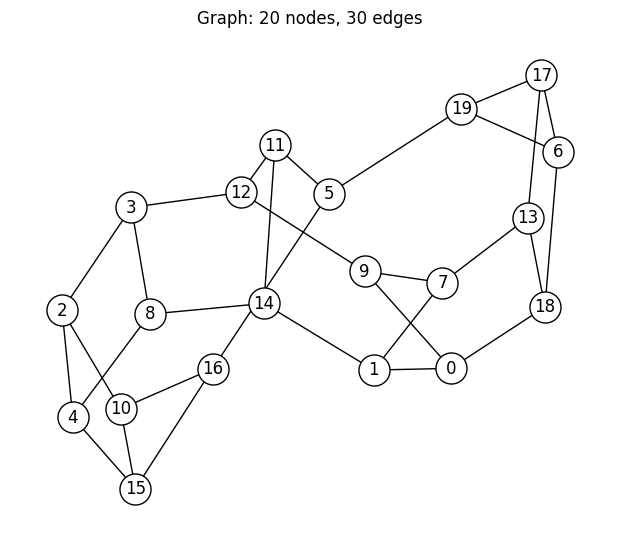

In [3]:
seed = 42
while True:
    G = nx.random_regular_graph(3, 20, seed=seed)
    if nx.is_connected(G):
        break
    seed += 1
print(f"Using seed = {seed} (smallest seed >= 42 producing a connected graph)")

num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()

pos = nx.spring_layout(G, seed=42)
plt.figure(figsize=(6, 5))
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color="white",
    node_size=500,
    edgecolors="black",
)
plt.title(f"Graph: {num_nodes} nodes, {num_edges} edges")
plt.show()

(pce-algorithm)=
## アルゴリズム

PCEはSciorilliら{cite:p}`10.48550/arXiv.2401.09421`が提案した、少ない量子ビット数で組合せ最適化を扱う手法です。標準的なQAOAは変数ごとに1量子ビットを使います。PCEは$N$変数の問題に対し$n = \mathcal{O}(N^{1/k})$量子ビットを使います。

### PCE符号化

PCEは相関演算子の次数$k > 1$を選び、スピン変数$i \in \{1, \dots, N\}$をそれぞれ別個の$k$体Pauli相関演算子$P_i$に割り当てます。各$P_i$は$\{X, Y, Z\}$から選んだ恒等演算子でない$k$個のPauli演算子のテンソル積で、$n$量子ビットのうち$k$個に作用します。$n$量子ビット上に存在するこのような相関演算子は$\binom{n}{k} \cdot 3^k$個なので、$n$は次を満たす最小の整数として選びます。

$$
\binom{n}{k} \cdot 3^k \;\ge\; N.
$$

$k = 2$ならば$n = \mathcal{O}(\sqrt{N})$、$k = 3$ならば$n = \mathcal{O}(N^{1/3})$となります。この$N = 20$のインスタンスでは、$k = 2$で$n = 3$量子ビットが必要です。これは$\binom{3}{2} \cdot 9 = 27 \ge 20$を満たす最小の整数です。変数から相関演算子への割り当ては決定的に決まります。$n$量子ビット上の$k$体Pauli文字列の固定列挙を1つ用意し、その先頭$N$個を変数$0, \dots, N-1$へ割り当てます。

### コスト関数

パラメータ付きアンザッツ状態$|\Psi(\boldsymbol{\theta})\rangle$が与えられたとき、PCEは離散的なスピン目的関数

$$
C(\mathbf{s}) \;=\; \sum_i h_i \, s_i \,+\, \sum_{i<j} J_{ij} \, s_i s_j
$$

を、各スピン$s_i$をtanh緩和した相関演算子期待値$\sigma_i(\boldsymbol{\theta}) = \tanh\bigl(\alpha\, \langle P_i \rangle\bigr)$に置き換え、さらに緩和変数の早い飽和を抑える4次の正則化項を加えることで、滑らかな代理損失関数$\mathcal{L}$へ変換します。tanh写像により$\sigma_i$は開区間$(-1, +1)$に入り、この領域では符号丸めで候補ビット列を復元できます。

$$
\mathcal{L}(\boldsymbol{\theta})
\;=\; \underbrace{\sum_i h_i \, \sigma_i \,+\, \sum_{i<j} J_{ij} \, \sigma_i \sigma_j}_{\mathcal{L}_{\text{data}}}
      \,+\, \mathcal{L}_{\text{reg}}, \qquad
\mathcal{L}_{\text{reg}}
\;=\; \beta \cdot \nu \cdot \!\left[ \frac{1}{N} \sum_i \sigma_i^2 \right]^{\!2}.
$$

データ項は接続された各ペアで$\sigma_i$と$\sigma_j$を逆符号へ引き寄せます。つまり$J_{ij} \sigma_i \sigma_j$が負になる方向へ働きます。正則化項は大きな緩和値にペナルティーを与えてこの圧力と釣り合いを取ります。これにより、オプティマイザを領域の滑らかな内部に保ち、劣ったビット列への早期収束を抑えます。

この損失には3つのハイパーパラメータ$\alpha$（tanhの鋭さ）、$\beta$（正則化項の強さ）、$\nu$（全体スケール）が含まれます。これらの値はオプティマイザの収束と最終的なビット列の品質に影響します。本チュートリアルで用いる具体的な値は元論文に従い、[](#pce-optimize-variational-parameters)で設定します。

MaxCutに限れば、スピンモデルは$h_i = 0$、各辺で$J_{ij} = +\tfrac{1}{2}$なので、データ項は隣接する$\sigma_i, \sigma_j$が逆符号となるとき最小になります。

### デコード

収束後、PCEは最適化された各相関演算子の期待値を、符号丸めによって離散スピンへ戻します。

$$
s_i \;=\; \operatorname{sgn}\!\bigl\langle P_i \bigr\rangle_{\boldsymbol{\theta}^*}
\;\in\; \{+1, -1\},
$$

すなわち$\langle P_i \rangle \ge 0$なら$s_i = +1$、それ以外なら$s_i = -1$とします。二値割り当ては$x_i = (1 - s_i) / 2$として復元されます。

## Qamomileでの実装

### `BinaryModel`と`PCEConverter`の構築

[](#problem-settings)で導出したIsing形式を`BinaryModel.from_ising`で構築します。係数は$h_i = 0$、各辺で$J_{ij} = 1/2$、定数項$-|E|/2$です。得られたスピンモデルと相関演算子の次数$k = 2$を`PCEConverter`に渡すと、コンバータが必要な量子ビット数を決めます。このスケーリングではスピンモデルのエネルギーがカット値の符号反転に等しくなります。カットが大きいほどエネルギーが低くなります。

In [4]:
quad = {(i, j): 0.5 for i, j in G.edges()}
ising_model = BinaryModel.from_ising(
    linear={},
    quad=quad,
    constant=-num_edges / 2,
)
converter = PCEConverter(ising_model, correlator_order=2)

spin_model = converter.spin_model
print(f"Number of variables  : {spin_model.num_bits}")
print(f"PCE qubit count      : {converter.num_qubits}")
print(f"Correlator order (k) : {converter.correlator_order}")
print(f"Compression ratio    : {spin_model.num_bits / converter.num_qubits:.1f}x")

assert spin_model.num_bits == 20
assert converter.num_qubits == 3
assert converter.correlator_order == 2

Number of variables  : 20
PCE qubit count      : 3
Correlator order (k) : 2
Compression ratio    : 6.7x


### 変数ごとのPauliオブザーバブルを確認する

`get_encoded_pauli_list()`は変数ごとに1つのHamiltonianを返します。各Hamiltonianは係数1の$k$体Pauli文字列をちょうど1つ含みます。これらが[](#pce-algorithm)で言及した$P_i$オブザーバブルです。最適化ループはアンザッツの量子カーネル内の`qmc.expval`で、それらの期待値を推定します。

In [5]:
observables = converter.get_encoded_pauli_list()

print(f"Total observables : {len(observables)}")
for i, P_i in enumerate(observables):
    print(f"  P_{i:2d}: {P_i}")

assert len(observables) == spin_model.num_bits
# 各オブザーバブルは係数1のk体Pauli文字列1つです。
for P_i in observables:
    coeffs = list(P_i.terms.values())
    assert len(coeffs) == 1 and abs(coeffs[0] - 1.0) < 1e-12

Total observables : 20
  P_ 0: Hamiltonian((X0, X1): 1.0)
  P_ 1: Hamiltonian((X0, Y1): 1.0)
  P_ 2: Hamiltonian((X0, Z1): 1.0)
  P_ 3: Hamiltonian((Y0, X1): 1.0)
  P_ 4: Hamiltonian((Y0, Y1): 1.0)
  P_ 5: Hamiltonian((Y0, Z1): 1.0)
  P_ 6: Hamiltonian((Z0, X1): 1.0)
  P_ 7: Hamiltonian((Z0, Y1): 1.0)
  P_ 8: Hamiltonian((Z0, Z1): 1.0)
  P_ 9: Hamiltonian((X0, X2): 1.0)
  P_10: Hamiltonian((X0, Y2): 1.0)
  P_11: Hamiltonian((X0, Z2): 1.0)
  P_12: Hamiltonian((Y0, X2): 1.0)
  P_13: Hamiltonian((Y0, Y2): 1.0)
  P_14: Hamiltonian((Y0, Z2): 1.0)
  P_15: Hamiltonian((Z0, X2): 1.0)
  P_16: Hamiltonian((Z0, Y2): 1.0)
  P_17: Hamiltonian((Z0, Z2): 1.0)
  P_18: Hamiltonian((X1, X2): 1.0)
  P_19: Hamiltonian((X1, Y2): 1.0)


### アンザッツの定義

PCEでは回路を自由に選べます。原論文では**Hardware-efficient ansatz**を使います。これは単一量子ビット回転と2量子ビットのエンタングルゲートを交互に積み重ねる構成です。本チュートリアルでは`qamomile.circuit.algorithm.basic`が提供する事前定義のレイヤ（`ry_layer`、`rz_layer`、`cx_entangling_layer`）を`depth`回スタックして使い、合計で$2 \cdot n \cdot \text{depth}$個の変分角度を持たせます。量子カーネルは$\langle P \rangle$を返します。`P`はトランスパイル時のbindingsで固定されるオブザーバブルなので、同じ量子カーネルを$P_i$ごとに1回ずつトランスパイルします。

:::{note}
Qamomileの回転ゲートは標準的な$1/2$係数を持ちます: $\text{RY}(\theta) = e^{-i \theta Y / 2}$、$\text{RZ}(\theta) = e^{-i \theta Z / 2}$。`thetas`ベクトルの各要素は変分パラメータです。オプティマイザがスケールできるため、この定数倍は最適な`thetas`値に吸収されます。したがって明示的に$2$を掛けず、`thetas[i]`をそのまま渡しています。
:::

In [6]:
@qmc.qkernel
def pce_ansatz(
    n: qmc.UInt,
    depth: qmc.UInt,
    thetas: qmc.Vector[qmc.Float],
    P: qmc.Observable,
) -> qmc.Float:
    q = qmc.qubit_array(n, name="q")
    for i in qmc.range(n):
        q[i] = qmc.h(q[i])
    for d in qmc.range(depth):
        offset = d * 2 * n
        q = ry_layer(q, thetas, offset)  # type: ignore[arg-type]
        q = rz_layer(q, thetas, offset + n)  # type: ignore[arg-type,operator]
        q = cx_entangling_layer(q)
    return qmc.expval(q, P)

アンザッツの構造を具体的に示すため、$n = 3$量子ビット、`depth = 1`（レイヤー数1）の回路図を示します。`P`は最初の符号化オブザーバブルに固定し、`thetas`はランタイムパラメータとして残します。

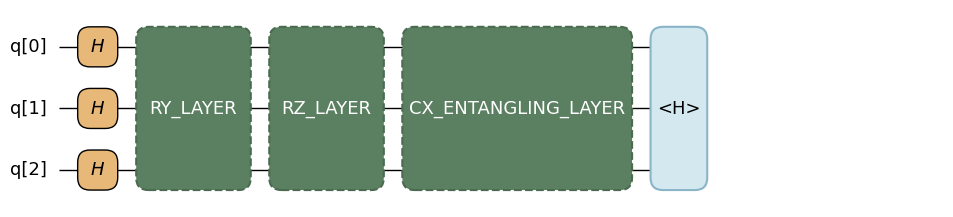

In [7]:
pce_ansatz.draw(n=3, depth=1, P=observables[0], fold_loops=False)

### オブザーバブルごとに1つの`ExecutableProgram`へとトランスパイルする

各$P_i$はトランスパイル時に固定する必要があるため、オブザーバブルごとに1回トランスパイルし、得られた`ExecutableProgram`をリストに保存します。各`transpiler.transpile(...)`は、トランスパイル済みのバックエンド回路とランタイムパラメータの再バインドに必要なメタデータをまとめた`ExecutableProgram`を返します。トランスパイル時の`bindings`は構造的な入力（`n`、`depth`、`P`）を固定し、`parameters=["thetas"]`は変分角度をオプティマイザが呼び出しのたびに変更できるランタイムパラメータとして残します。

In [8]:
transpiler = QiskitTranspiler()

n = converter.num_qubits
depth = 3
num_thetas = 2 * n * depth

executables = [
    transpiler.transpile(
        pce_ansatz,
        bindings={"n": n, "depth": depth, "P": P_i},
        parameters=["thetas"],
    )
    for P_i in observables
]

print(f"Executables cached : {len(executables)}")
print(f"Variational params : {num_thetas} (= 2 * n * depth)")

assert len(executables) == len(observables)
assert num_thetas == 2 * n * depth

Executables cached : 20
Variational params : 18 (= 2 * n * depth)


(pce-optimize-variational-parameters)=
### 変分パラメータの最適化

古典ループは現在の`thetas`で全オブザーバブルに対し$\langle P_i \rangle$を推定し、得られた値を[](#pce-algorithm)のtanh緩和損失（データ項＋正則化項）に代入し、`scipy.optimize.minimize`に角度を更新させます。

損失の3つのハイパーパラメータは元論文に従って次のように設定します。

- $\alpha$（tanhの鋭さ）: $\alpha = N^{k/2}$と設定します。$N$はグラフのノード数、$k$は相関演算子の次数で、本チュートリアル（20ノード、$k = 2$）では$\alpha = 20$となります。
- $\beta$（正則化項の強さ）: 論文においてチューニング済みの固定値$1/2$を使います。
- $\nu$（全体スケール）: Edwards-ErdősのMaxCut下界$\nu = |E|/2 + (N - 1)/4$を使用します。

In [9]:
executor = transpiler.executor()
docs_test_mode = os.environ.get("QAMOMILE_DOCS_TEST") == "1"
maxiter = 10 if docs_test_mode else 100

# https://doi.org/10.48550/arXiv.2401.09421 のハイパーパラメータ:
#   alpha = N^(k/2) (N = ノード数、k = PCEの相関演算子の次数)
#   beta  = 1/2 (正則化項の強さ)
#   nu    = |E| / 2 + (N - 1) / 4 (MaxCutに対するEdwards-Erdős下界)
N = spin_model.num_bits
k = converter.correlator_order
alpha = float(N ** (k / 2))
beta = 0.5
nu = num_edges / 2 + (N - 1) / 4
print(f"alpha = {alpha}, beta = {beta}, nu = {nu}")

cost_history: list[float] = []


def measure_expectations(thetas: list[float]) -> list[float]:
    return [
        exe.run(executor, bindings={"thetas": thetas}).result() for exe in executables
    ]


def loss(params: np.ndarray) -> float:
    thetas = list(params)
    expvals = measure_expectations(thetas)
    relaxed = [np.tanh(alpha * e) for e in expvals]

    # データ項: スピン目的関数の滑らかな代理損失関数。
    L_data = 0.0
    for (i, j), J_ij in spin_model.quad.items():
        L_data += J_ij * relaxed[i] * relaxed[j]
    for i, h_i in spin_model.linear.items():
        L_data += h_i * relaxed[i]

    # 正則化項: beta * nu * [(1/N) sum tanh^2(alpha <P_i>)]^2.
    mean_sq = sum(r**2 for r in relaxed) / N
    L_reg = beta * nu * mean_sq**2

    L_total = L_data + L_reg
    cost_history.append(L_total)
    return L_total


rng = np.random.default_rng(42)
initial_params = rng.uniform(-np.pi, np.pi, num_thetas)

res = minimize(loss, initial_params, method="BFGS", options={"maxiter": maxiter})

print(f"Final loss: {res.fun:+.4f}")

alpha = 20.0, beta = 0.5, nu = 19.75


Final loss: -3.4750


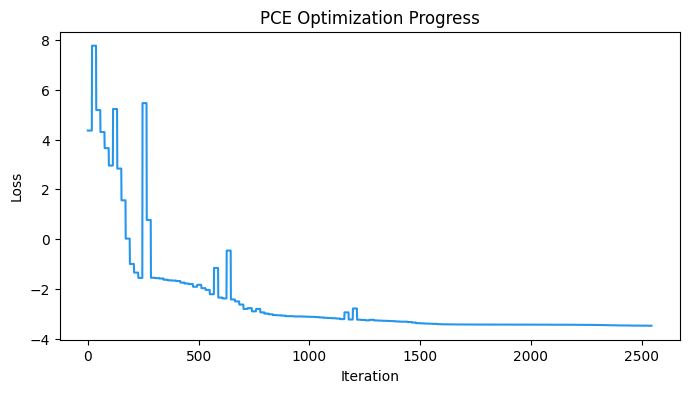

In [10]:
plt.figure(figsize=(8, 4))
plt.plot(cost_history, color="#2696EB")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("PCE Optimization Progress")
plt.show()

(pce-decode-optimized-expectations)=
### 最適化済みの期待値をデコードする

`PCEConverter.decode(expectations)`は変数ごとの期待値を受け取り、それぞれを符号丸めしてスピンに変換し、入力モデルと同じvartypeで1サンプルの`BinarySampleSet`を返します。ここでは`ising_model`を`BinaryModel.from_ising`で構築したため、vartypeはSPINです。出力されるエネルギーは[](#problem-settings)で設定した規約（エネルギー＝$-\,\text{cut}$）に従うので、デコード後のエネルギーはカット値の負の値です。

In [11]:
final_expectations = measure_expectations(list(res.x))
sampleset = converter.decode(final_expectations)
# ``PCEConverter`` を ``BinaryModel`` (上の ``ising_model``) から構築したので、
# ``decode`` は ``BinarySampleSet`` を返す。型上は ``BinarySampleSet | SampleSet``
# の Union (converter は OMMX ``Instance`` も受け入れるため) なので、ここで
# narrow して下の ``.vartype`` / ``.energy`` / ``.samples`` を通す。
assert isinstance(sampleset, BinarySampleSet)

print("Final per-variable expectations:")
for i, e in enumerate(final_expectations):
    print(f"  <P_{i:2d}> = {e:+.4f}")
print()
print(f"Decoded vartype : {sampleset.vartype}")
print(f"Decoded energy  : {sampleset.energy[0]:+.4f}")

Final per-variable expectations:
  <P_ 0> = -0.0848
  <P_ 1> = +0.0894
  <P_ 2> = +0.3133
  <P_ 3> = -0.0118
  <P_ 4> = -0.0372
  <P_ 5> = -0.2572
  <P_ 6> = -0.0396
  <P_ 7> = -0.0292
  <P_ 8> = +0.0418
  <P_ 9> = +0.2510
  <P_10> = -0.0481
  <P_11> = +0.2302
  <P_12> = -0.2536
  <P_13> = -0.0224
  <P_14> = -0.0883
  <P_15> = +0.0071
  <P_16> = +0.0680
  <P_17> = +0.0666
  <P_18> = +0.3815
  <P_19> = +0.0159

Decoded vartype : SPIN
Decoded energy  : -26.0000


(pce-result)=
## 結果

(pce-classical-baseline)=
### 古典ベースライン（全探索）

$2^{20} = 1{,}048{,}576$通りすべてのスピン配置を列挙すると、約100万個の割り当てを調べることになります。単純なPythonループでは多すぎますが、ベクトル化したNumPyを1回通すだけなら短時間で完了します。各配置は整数でラベル付けし、ビット$i$が$0$なら$s_i = +1$、$1$なら$s_i = -1$と対応付けたうえで、$s_i \neq s_j$となる辺の数を数えます。これで次のサブセクションでPCEの結果と比較するための真の最適値が得られます。

In [12]:
assignments = np.arange(2**num_nodes, dtype=np.int64)
cuts = np.zeros(2**num_nodes, dtype=np.int32)
for i, j in G.edges():
    s_i = 1 - 2 * ((assignments >> i) & 1)  # bit 0 → +1, bit 1 → -1
    s_j = 1 - 2 * ((assignments >> j) & 1)
    cuts += (s_i != s_j).astype(np.int32)

best_cut = int(cuts.max())
optimal_assignment_ints = np.flatnonzero(cuts == best_cut)
print(f"Optimal MaxCut value         : {best_cut}")
print(f"Number of optimal partitions : {len(optimal_assignment_ints)}")

# グラフseedは固定なので、全探索の最適値は決定的に決まります。
assert best_cut == 26

Optimal MaxCut value         : 26
Number of optimal partitions : 12


### デコードと結果の分析

#### ベストカット

デコードされたスピン割り当てをグラフ分割に変換し、[](#pce-classical-baseline)の全探索による厳密解と比較します。整合性チェックとして、カット値は[](#pce-decode-optimized-expectations)で出力したスピンエネルギーの$-1$倍と一致するはずです。

In [13]:
sample = sampleset.samples[0]
spins = [sample[i] for i in range(num_nodes)]
pce_cut = sum(1 for i, j in G.edges() if spins[i] != spins[j])

print(f"PCE spin assignment : {spins}")
print(f"PCE cut value       : {pce_cut}")
print(f"Brute-force optimum : {best_cut}")
print(f"Approximation ratio : {pce_cut / best_cut:.3f}")

PCE spin assignment : [-1, 1, 1, -1, -1, -1, -1, -1, 1, 1, -1, 1, -1, -1, -1, 1, 1, 1, 1, 1]
PCE cut value       : 26
Brute-force optimum : 26
Approximation ratio : 1.000


#### 解の可視化

各ノードを所属するパーティション側で色分けします。色が異なるノード同士は、カットの反対側に位置します。

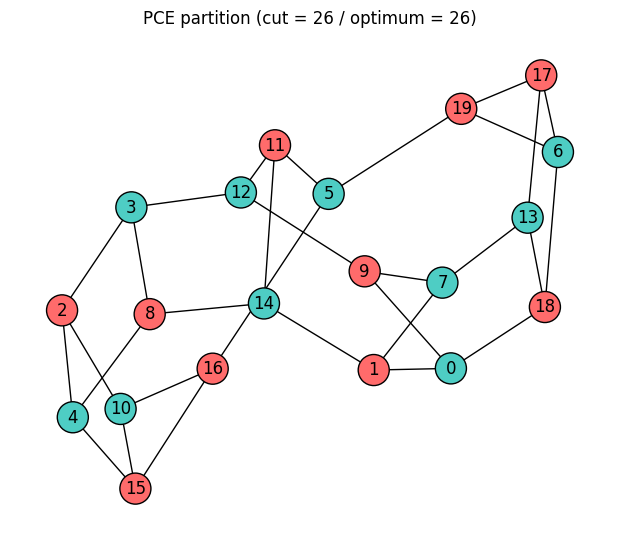

In [14]:
color_map = ["#FF6B6B" if spins[i] == 1 else "#4ECDC4" for i in range(num_nodes)]
plt.figure(figsize=(6, 5))
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=color_map,
    node_size=500,
    edgecolors="black",
)
plt.title(f"PCE partition (cut = {pce_cut} / optimum = {best_cut})")
plt.show()

## まとめ

本チュートリアルでは、20ノードの3-正則グラフ上のMaxCut問題をPauli Correlation Encoding（PCE）でエンコードし、相関演算子の符号化からデコードによるスピン割り当ての復元までを行う、Qamomileのワークフロー全体を扱いました。

- **量子ビットのリソース効率:** PCEは20個のスピン変数を、2体のPauli相関演算子によってわずか3量子ビットで表現しました。変数あたり1量子ビットを使うQAOA符号化と比べて約7倍の削減です。
- **代理損失関数による最適化:** 変分ループでは、エネルギーを直接最小化するのではなく、tanh緩和による代理損失関数を最小化しました。デコードした割り当ては全探索の最適値と一致しました。
- **Qamomileによるエンドツーエンドの流れ:** `PCEConverter`が与えられた古典変数を符号化し、対応するオブザーバブルを`get_encoded_pauli_list`で取得しました。`@qkernel`で実装されたHardware-efficient ansatzと`qmc.expval`を利用して各相関演算子の期待値を推定し、`QiskitTranspiler`が`ExecutableProgram`を生成して、オプティマイザを使ってパラメータを調整しました。最後に`converter.decode`を用いて調整後のパラメータを使って得られた期待値を符号丸めして対応する古典変数を取り出しました。

今回の`PCEConverter`のワークフローは、量子ビット数がボトルネックになる任意のQUBO/Ising組合せ最適化問題に応用できます。自分の`BinaryModel`を差し替えれば、上記の符号化・トランスパイル・デコードの手順をそのまま再利用できます。